# 牛散跟单回测分析

基于特特股(tetegu.com)牛散新进/增持数据，分析各牛散的跟单成功率，
找出值得跟踪的牛散。

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

for _s in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot']:
    if _s in plt.style.available:
        plt.style.use(_s)
        break

_cn_font = 'Heiti TC'
matplotlib.rcParams['font.sans-serif'] = [_cn_font, 'PingFang HK', 'Noto Sans SC', 'SimHei']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

import glob
xlsx_files = sorted(glob.glob('niusan_*.xlsx'))
latest_file = xlsx_files[-1] if xlsx_files else 'niusan_20260315.xlsx'
print(f'加载: {latest_file}')
df = pd.read_excel(latest_file)
df['股票代码'] = df['股票代码'].astype(str).str.zfill(6)
df['报告期'] = pd.to_datetime(df['报告期'])
df['跟踪买入日'] = pd.to_datetime(df['跟踪买入日'])
print(f'总记录: {len(df)}  |  牛散: {df["牛散"].nunique()}  |  股票: {df["股票代码"].nunique()}')
df.head()

总记录: 1186  |  牛散: 49  |  股票: 715


,牛散,股票代码,股票名称,持股变动,报告期,报告期收盘价,跟踪买入日,跟踪成本价,持仓1月后日期,持仓1月后价,持仓1月收益率,持仓2月后日期,持仓2月后价,持仓2月收益率,持仓3月后日期,持仓3月后价,持仓3月收益率
0,凌静芝,301148,嘉戎技术,增持,2025-11-14,33.03,2026-02-24,52.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,凌静芝,301148,嘉戎技术,新进,2025-09-30,31.61,2025-12-30,45.72,2026-01-30,52.81,0.1551,2026-03-02,53.88,0.1785,NaN,NaN,NaN
2,凌静芝,003041,真爱美家,新进,2025-09-30,23.93,2025-12-30,49.50,2026-01-30,66.48,0.3430,2026-03-02,55.98,0.1309,NaN,NaN,NaN
3,凌静芝,300771,智莱科技,新进,2025-09-30,12.39,2025-12-30,15.30,2026-01-30,15.01,-0.0190,2026-03-02,14.93,-0.0242,NaN,NaN,NaN
4,凌静芝,301043,绿岛风,新进,2025-09-30,49.82,2025-12-30,66.83,2026-01-30,71.14,0.0645,2026-03-02,57.58,-0.1384,NaN,NaN,NaN


## 1. 全局收益率概览

In [3]:
ret_cols = ['持仓1月收益率', '持仓2月收益率', '持仓3月收益率']
labels = ['1个月', '2个月', '3个月']

summary = []
for col, label in zip(ret_cols, labels):
    v = df[col].dropna()
    summary.append({
        '持仓期': label,
        '样本数': len(v),
        '平均收益率': f'{v.mean():.2%}',
        '中位收益率': f'{v.median():.2%}',
        '胜率(>0)': f'{(v>0).mean():.2%}',
        '大赚率(>20%)': f'{(v>0.2).mean():.2%}',
        '亏损率(<-10%)': f'{(v<-0.1).mean():.2%}',
        '最大收益': f'{v.max():.2%}',
        '最大亏损': f'{v.min():.2%}',
    })

pd.DataFrame(summary).set_index('持仓期')

,样本数,平均收益率,中位收益率,胜率(>0),大赚率(>20%),亏损率(<-10%),最大收益,最大亏损
持仓期,,,,,,,,
1个月,1181,3.29%,2.10%,60.54%,8.30%,11.52%,140.57%,-56.84%
2个月,1178,8.01%,4.18%,64.86%,16.72%,12.48%,341.67%,-69.47%
3个月,861,9.36%,3.18%,57.72%,21.25%,16.61%,417.78%,-47.34%


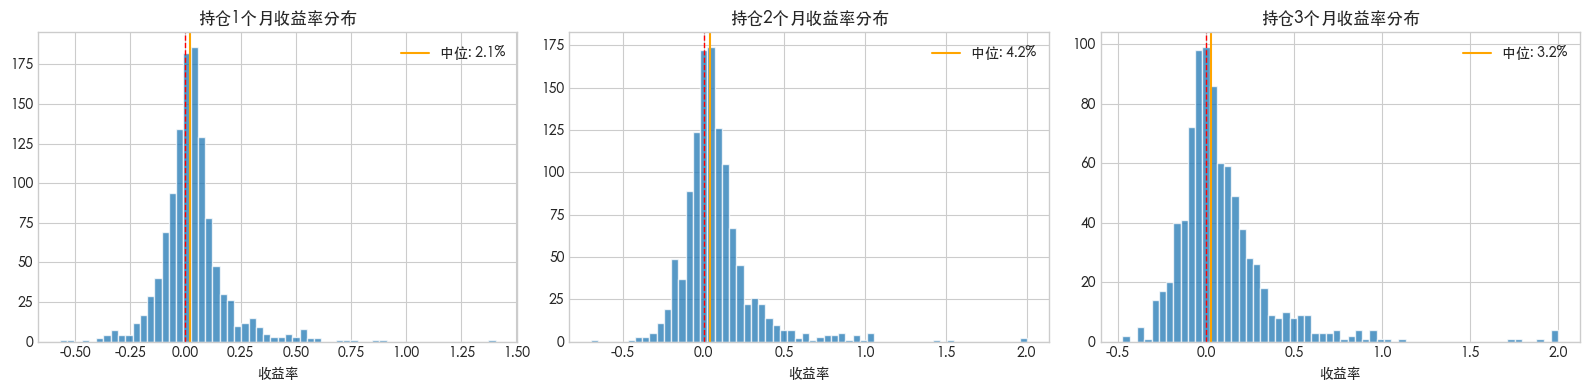

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label in zip(axes, ret_cols, labels):
    v = df[col].dropna()
    v_clipped = v.clip(-1, 2)
    ax.hist(v_clipped, bins=60, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(v.median(), color='orange', linestyle='-', linewidth=1.5, label=f'中位: {v.median():.1%}')
    ax.set_title(f'持仓{label}收益率分布')
    ax.set_xlabel('收益率')
    ax.legend()
plt.tight_layout()
plt.show()

## 2. 新进 vs 增持 对比

In [5]:
compare = []
for change_type in ['新进', '增持']:
    sub = df[df['持股变动'] == change_type]
    for col, label in zip(ret_cols, labels):
        v = sub[col].dropna()
        compare.append({
            '类型': change_type,
            '持仓期': label,
            '样本': len(v),
            '平均收益': f'{v.mean():.2%}',
            '中位收益': f'{v.median():.2%}',
            '胜率': f'{(v>0).mean():.2%}',
        })

pd.DataFrame(compare)

,类型,持仓期,样本,平均收益,中位收益,胜率
0,新进,1个月,580,2.66%,1.80%,57.41%
1,新进,2个月,579,7.67%,3.84%,63.73%
2,新进,3个月,407,8.88%,3.24%,57.74%
3,增持,1个月,601,3.90%,2.49%,63.56%
4,增持,2个月,599,8.33%,4.30%,65.94%
5,增持,3个月,454,9.80%,3.00%,57.71%


## 3. 各牛散跟单表现排行（核心分析）

综合评分方法：对每位牛散计算1/2/3个月的胜率和平均收益率，
并加权计算综合得分。要求最少5条有效记录。

In [6]:
MIN_SAMPLES = 5

records = []
for name, g in df.groupby('牛散'):
    row = {'牛散': name, '总记录数': len(g)}
    valid = True
    for col, label in zip(ret_cols, labels):
        v = g[col].dropna()
        if len(v) < MIN_SAMPLES:
            valid = False
            break
        row[f'{label}_样本'] = len(v)
        row[f'{label}_平均收益'] = v.mean()
        row[f'{label}_中位收益'] = v.median()
        row[f'{label}_胜率'] = (v > 0).mean()
        row[f'{label}_盈亏比'] = v[v>0].mean() / abs(v[v<0].mean()) if (v<0).any() and (v>0).any() else np.nan
    if valid:
        records.append(row)

rank = pd.DataFrame(records)

# 综合得分：胜率(40%) + 平均收益(40%) + 盈亏比(20%)，各期等权
for label in labels:
    wr = rank[f'{label}_胜率']
    mr = rank[f'{label}_平均收益'].rank(pct=True)
    pr = rank[f'{label}_盈亏比'].rank(pct=True)
    rank[f'{label}_分项得分'] = wr * 0.4 + mr * 0.4 + pr.fillna(0.5) * 0.2

score_cols = [f'{l}_分项得分' for l in labels]
rank['综合得分'] = rank[score_cols].mean(axis=1)
rank.sort_values('综合得分', ascending=False, inplace=True)
rank.reset_index(drop=True, inplace=True)

print(f'满足最低 {MIN_SAMPLES} 条记录的牛散: {len(rank)} 位')

满足最低 5 条记录的牛散: 44 位


In [7]:
display_cols = ['牛散', '总记录数', '综合得分']
for label in labels:
    display_cols += [f'{label}_样本', f'{label}_胜率', f'{label}_平均收益', f'{label}_中位收益', f'{label}_盈亏比']

show = rank[display_cols].copy()
for label in labels:
    show[f'{label}_胜率'] = show[f'{label}_胜率'].map('{:.1%}'.format)
    show[f'{label}_平均收益'] = show[f'{label}_平均收益'].map('{:.2%}'.format)
    show[f'{label}_中位收益'] = show[f'{label}_中位收益'].map('{:.2%}'.format)
    show[f'{label}_盈亏比'] = show[f'{label}_盈亏比'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
show['综合得分'] = show['综合得分'].map('{:.3f}'.format)

show

,牛散,总记录数,综合得分,1个月_样本,1个月_胜率,1个月_平均收益,1个月_中位收益,1个月_盈亏比,2个月_样本,2个月_胜率,2个月_平均收益,2个月_中位收益,2个月_盈亏比,3个月_样本,3个月_胜率,3个月_平均收益,3个月_中位收益,3个月_盈亏比
0,王成华,32,0.838,32,68.8%,5.93%,4.74%,1.93,31,87.1%,17.35%,14.15%,3.89,22,72.7%,24.04%,14.97%,5.84
1,王冬梅,10,0.813,10,80.0%,6.83%,5.91%,2.92,10,80.0%,12.53%,8.92%,9.86,9,55.6%,12.16%,0.34%,7.82
2,钟格,31,0.809,30,66.7%,9.65%,6.06%,2.19,30,66.7%,12.39%,6.80%,2.37,24,83.3%,24.87%,11.77%,3.84
3,张勇,14,0.764,14,64.3%,5.70%,2.11%,1.32,14,64.3%,34.99%,4.08%,5.95,13,53.8%,38.11%,0.85%,11.20
4,林新,42,0.763,42,85.7%,6.30%,4.18%,1.74,41,85.4%,9.46%,7.60%,1.71,24,70.8%,14.08%,5.40%,4.07
5,宁琛,17,0.763,17,58.8%,6.41%,6.93%,2.42,17,70.6%,12.96%,9.90%,2.23,16,75.0%,16.09%,14.31%,3.70
6,章安,32,0.751,32,62.5%,3.75%,3.07%,1.99,32,78.1%,9.75%,5.16%,3.63,29,79.3%,16.79%,10.45%,6.12
7,张伟,21,0.744,21,71.4%,9.48%,4.06%,2.70,21,76.2%,11.28%,7.16%,1.94,14,71.4%,9.90%,7.47%,2.58
8,刘伟,13,0.743,13,92.3%,4.64%,1.95%,0.55,13,76.9%,12.51%,5.87%,4.02,9,77.8%,12.17%,3.72%,3.03
9,张秀,38,0.734,38,76.3%,4.78%,1.96%,1.36,38,78.9%,11.34%,5.66%,2.52,21,66.7%,15.57%,6.42%,3.94


## 4. TOP 牛散可视化

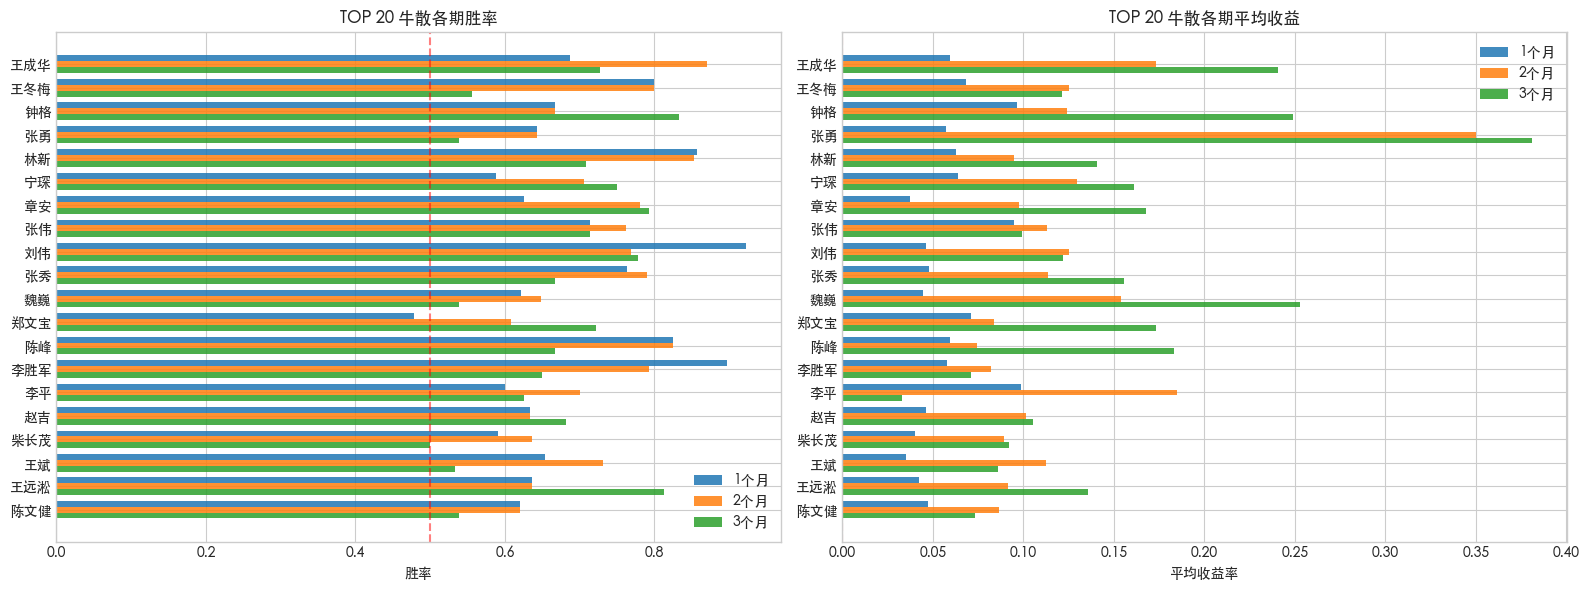

In [18]:
top_n = min(20, len(rank))
top = rank.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：各期胜率
ax = axes[0]
x = np.arange(top_n)
width = 0.25
for i, label in enumerate(labels):
    vals = top[f'{label}_胜率'].values
    ax.barh(x + i*width, vals, width, label=label, alpha=0.85)
ax.set_yticks(x + width)
ax.set_yticklabels(top['牛散'].values)
ax.set_xlabel('胜率')
ax.set_title(f'TOP {top_n} 牛散各期胜率')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.invert_yaxis()

# 右图：各期平均收益
ax = axes[1]
for i, label in enumerate(labels):
    vals = top[f'{label}_平均收益'].values
    ax.barh(x + i*width, vals, width, label=label, alpha=0.85)
ax.set_yticks(x + width)
ax.set_yticklabels(top['牛散'].values)
ax.set_xlabel('平均收益率')
ax.set_title(f'TOP {top_n} 牛散各期平均收益')
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 5. 牛散胜率-收益率散点图（气泡大小=样本数）

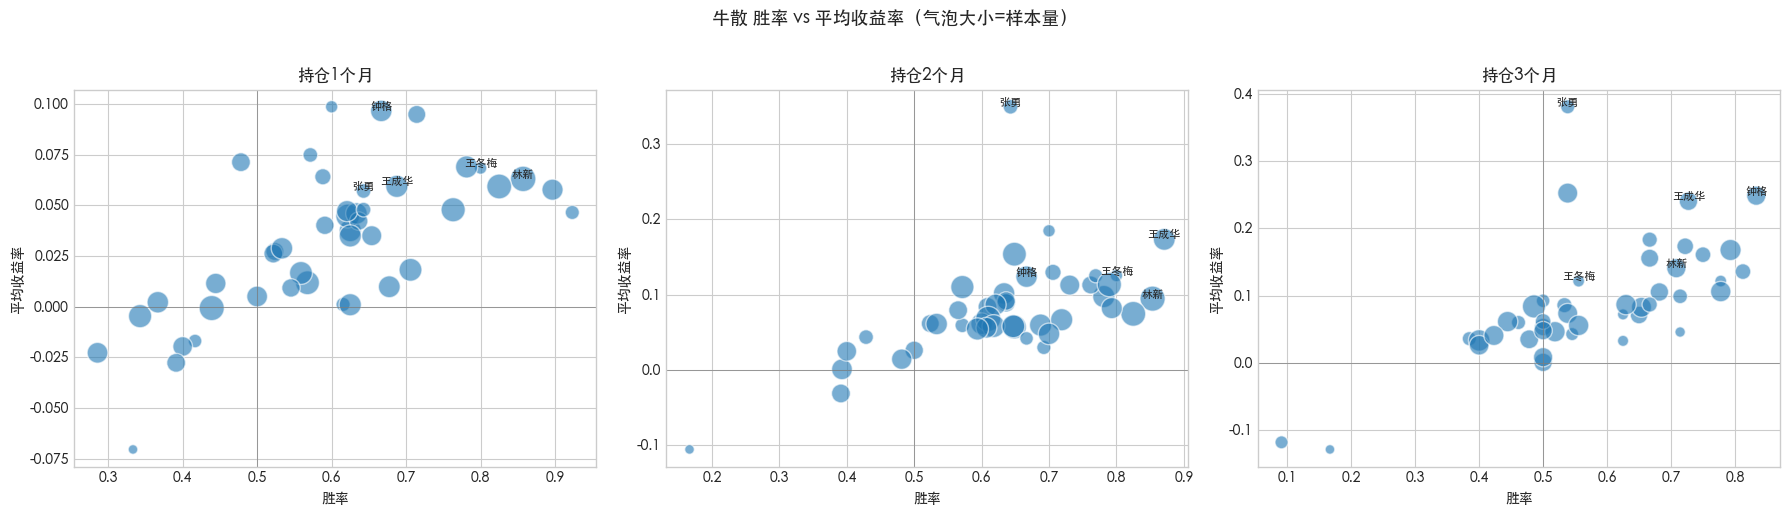

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label in zip(axes, labels):
    x_val = rank[f'{label}_胜率']
    y_val = rank[f'{label}_平均收益']
    sizes = rank[f'{label}_样本'] * 8
    ax.scatter(x_val, y_val, s=sizes, alpha=0.6, edgecolors='white')

    # 标注 TOP5
    for _, r in rank.head(5).iterrows():
        ax.annotate(r['牛散'],
                    (r[f'{label}_胜率'], r[f'{label}_平均收益']),
                    fontsize=8, ha='center', va='bottom')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0.5, color='gray', linewidth=0.5)
    ax.set_xlabel('胜率')
    ax.set_ylabel('平均收益率')
    ax.set_title(f'持仓{label}')

plt.suptitle('牛散 胜率 vs 平均收益率（气泡大小=样本量）', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. 按报告期分组的收益率趋势

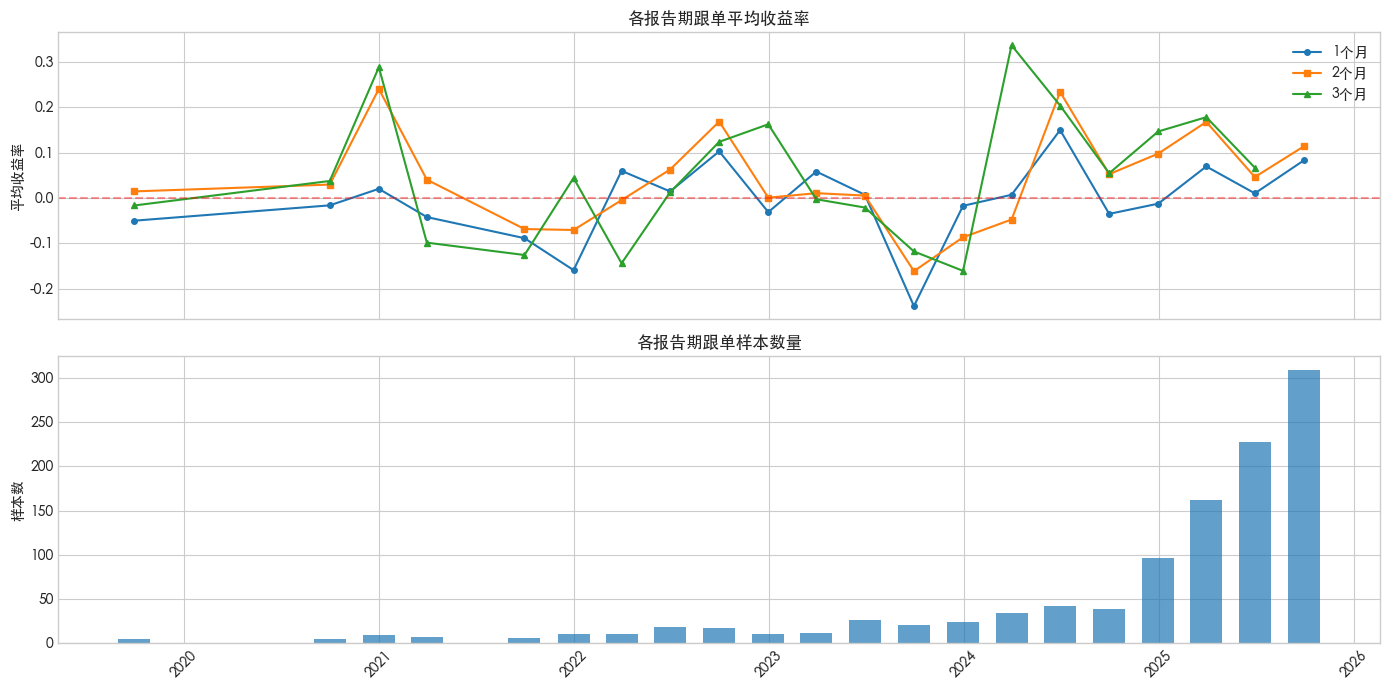

In [20]:
period_stats = df.groupby('报告期').agg(
    样本数=('持仓1月收益率', 'count'),
    一月平均=('持仓1月收益率', 'mean'),
    一月胜率=('持仓1月收益率', lambda x: (x.dropna()>0).mean()),
    二月平均=('持仓2月收益率', 'mean'),
    三月平均=('持仓3月收益率', 'mean'),
).sort_index()

period_stats = period_stats[period_stats['样本数'] >= 5]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(period_stats.index, period_stats['一月平均'], 'o-', label='1个月', markersize=4)
ax1.plot(period_stats.index, period_stats['二月平均'], 's-', label='2个月', markersize=4)
ax1.plot(period_stats.index, period_stats['三月平均'], '^-', label='3个月', markersize=4)
ax1.axhline(0, color='red', linestyle='--', alpha=0.4)
ax1.set_ylabel('平均收益率')
ax1.set_title('各报告期跟单平均收益率')
ax1.legend()

ax2.bar(period_stats.index, period_stats['样本数'], width=60, alpha=0.7)
ax2.set_ylabel('样本数')
ax2.set_title('各报告期跟单样本数量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. TOP 牛散最新持仓明细

列出综合得分前10的牛散，其最新报告期的新进/增持股票。

In [21]:
top_names = rank.head(10)['牛散'].tolist()
latest_period = df['报告期'].max()

latest = df[(df['牛散'].isin(top_names)) & (df['报告期'] == latest_period)].copy()
latest = latest.merge(rank[['牛散', '综合得分']], on='牛散', how='left')
latest.sort_values(['综合得分', '牛散'], ascending=[False, True], inplace=True)

show_cols = ['牛散', '综合得分', '股票代码', '股票名称', '持股变动',
             '报告期', '跟踪成本价', '持仓1月收益率', '持仓2月收益率']
available = [c for c in show_cols if c in latest.columns]
result = latest[available].copy()

for c in result.columns:
    if '收益率' in c:
        result[c] = result[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
    elif c == '综合得分':
        result[c] = result[c].map('{:.3f}'.format)

print(f'最新报告期: {latest_period.strftime("%Y-%m-%d")}  |  TOP10牛散持仓 {len(result)} 条')
result

最新报告期: 2025-11-27  |  TOP10牛散持仓 0 条


,牛散,综合得分,股票代码,股票名称,持股变动,报告期,跟踪成本价,持仓1月收益率,持仓2月收益率


## 8. 多牛散共同持仓

在最新报告期中被多位TOP牛散同时新进/增持的股票，值得重点关注。

In [22]:
top20_names = rank.head(20)['牛散'].tolist()
latest_all = df[(df['牛散'].isin(top20_names)) & (df['报告期'] == latest_period)]

stock_agg = latest_all.groupby(['股票代码', '股票名称']).agg(
    牛散数量=('牛散', 'nunique'),
    牛散名单=('牛散', lambda x: '、'.join(sorted(x.unique()))),
    平均1月收益=('持仓1月收益率', 'mean'),
).reset_index()

stock_agg = stock_agg.sort_values('牛散数量', ascending=False)
stock_agg['平均1月收益'] = stock_agg['平均1月收益'].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

print(f'最新报告期 TOP20 牛散持仓中，被多人持有的股票：')
stock_agg[stock_agg['牛散数量'] >= 2]

最新报告期 TOP20 牛散持仓中，被多人持有的股票：


,股票代码,股票名称,牛散数量,牛散名单,平均1月收益


## 9. 结论

根据综合得分筛选出跟单成功率最高的牛散。

In [23]:
print('='*60)
print('跟单成功率最高的牛散 TOP 10')
print('='*60)
for i, (_, r) in enumerate(rank.head(10).iterrows(), 1):
    name = r['牛散']
    score = r['综合得分']
    n = int(r['总记录数'])
    wr1 = r['1个月_胜率']
    wr2 = r['2个月_胜率']
    wr3 = r['3个月_胜率']
    mr1 = r['1个月_平均收益']
    mr2 = r['2个月_平均收益']
    mr3 = r['3个月_平均收益']
    print(f'\n{i}. {name}  (综合得分: {score:.3f}, 记录数: {n})')
    print(f'   1月: 胜率{wr1:.0%} 平均{mr1:.1%}  |  '
          f'2月: 胜率{wr2:.0%} 平均{mr2:.1%}  |  '
          f'3月: 胜率{wr3:.0%} 平均{mr3:.1%}')

跟单成功率最高的牛散 TOP 10

1. 王成华  (综合得分: 0.838, 记录数: 32)
   1月: 胜率69% 平均5.9%  |  2月: 胜率87% 平均17.3%  |  3月: 胜率73% 平均24.0%

2. 王冬梅  (综合得分: 0.813, 记录数: 10)
   1月: 胜率80% 平均6.8%  |  2月: 胜率80% 平均12.5%  |  3月: 胜率56% 平均12.2%

3. 钟格  (综合得分: 0.809, 记录数: 31)
   1月: 胜率67% 平均9.7%  |  2月: 胜率67% 平均12.4%  |  3月: 胜率83% 平均24.9%

4. 张勇  (综合得分: 0.764, 记录数: 14)
   1月: 胜率64% 平均5.7%  |  2月: 胜率64% 平均35.0%  |  3月: 胜率54% 平均38.1%

5. 林新  (综合得分: 0.763, 记录数: 42)
   1月: 胜率86% 平均6.3%  |  2月: 胜率85% 平均9.5%  |  3月: 胜率71% 平均14.1%

6. 宁琛  (综合得分: 0.763, 记录数: 17)
   1月: 胜率59% 平均6.4%  |  2月: 胜率71% 平均13.0%  |  3月: 胜率75% 平均16.1%

7. 章安  (综合得分: 0.751, 记录数: 32)
   1月: 胜率62% 平均3.7%  |  2月: 胜率78% 平均9.7%  |  3月: 胜率79% 平均16.8%

8. 张伟  (综合得分: 0.744, 记录数: 21)
   1月: 胜率71% 平均9.5%  |  2月: 胜率76% 平均11.3%  |  3月: 胜率71% 平均9.9%

9. 刘伟  (综合得分: 0.743, 记录数: 13)
   1月: 胜率92% 平均4.6%  |  2月: 胜率77% 平均12.5%  |  3月: 胜率78% 平均12.2%

10. 张秀  (综合得分: 0.734, 记录数: 38)
   1月: 胜率76% 平均4.8%  |  2月: 胜率79% 平均11.3%  |  3月: 胜率67% 平均15.6%
